
# Four-point sensitivities

In this example, we illustrate how to visualize the sensitivities of four-point
arrays. You can easily loop over the plotting command to create something like:
https://www.youtube.com/watch?v=lt1qV-2d5Ps


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import os

In [4]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/line01/jacobian_p5_DD", exist_ok=True)

filename = r'data\line01\og_fromtomsnotes_mytopo\project_5\Dipole-Dipole_1-2018-06-11-161704.dat'
data = ert.load(filename)
print(data)

xs = np.array([s.x() for s in data.sensors()])  # an array of all elec x-positions along line
data_min = xs.min(); data_max = xs.max()
print(data_min, data_max)

10/03/26 - 12:06:47 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas
Data: Sensors: 81 data: 1469, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']
0.0 400.0


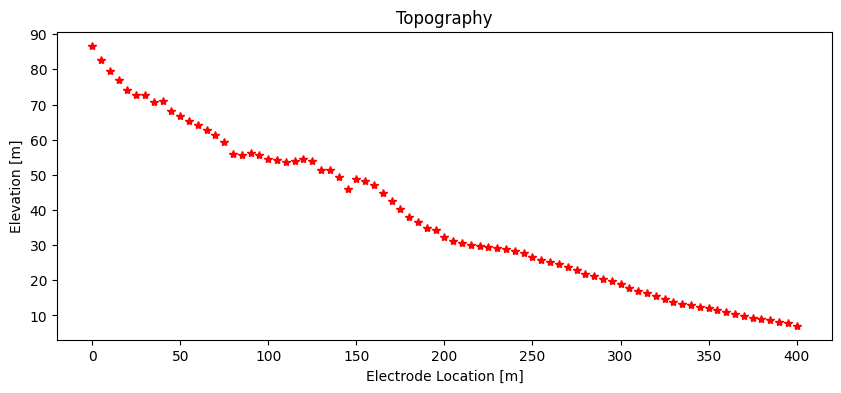

In [7]:
topo = []

topo_file = r'data\line01\og_fromtomsnotes_mytopo\line01_mytopo.txt'

with open(topo_file) as f: 
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        parts = line.split()  # split using whitespace
        if len(parts) == 2:  # if data has 2 columns it is topo data so add to the list
            topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

topo = topo[np.argsort(topo[:,0])]

x_elec = pg.x(data)  # get x pos of all electrodes
z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))

# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# set electrode positions in data
data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

# ensure arrays
x_elec = np.array(pg.x(data))
z_interp = np.array(z_interp)

plt.figure(figsize=(10,4))
plt.plot(x_elec, z_interp, 'r*')
plt.xlabel('Electrode Location [m]')
plt.ylabel('Elevation [m]')
plt.title('Topography')
plt.show()

We start by creating a ERT data container with three four-point arrays.



In [28]:
scheme = pg.DataContainerERT()

nelecs = 81
pos = np.zeros((nelecs, 2))
pos[:, 0] = np.linspace(5, 25, nelecs)
scheme.setSensorPositions(pos)

measurements = np.array((
    [0, 3, 6, 9],  # Dipole-Dipole
    [0, 9, 3, 6],  # Wenner
    [0, 9, 4, 5]   # Schlumberger
))

for i, elec in enumerate("abmn"):
    scheme[elec] = measurements[:,i]

scheme["k"] = ert.createGeometricFactors(scheme)

10/03/26 - 12:44:19 - pyGIMLi - INFO - Save RVector binary
10/03/26 - 12:44:19 - pyGIMLi - INFO - Cache stored: C:\Users\sydne\AppData\Roaming\pygimli\Cache\13378742678749378193


Now we set up a 2D mesh.



In [29]:
world = mt.createWorld(start=[0, 0], end=[30, -5], worldMarker=True)
for pos in scheme.sensorPositions():
    world.createNode(pos)

mesh = mt.createMesh(world, area=.05, quality=33, marker=1)

As a last step we invoke the ERT manager and calculate the Jacobian for a
homogeneous half-space.



In [30]:
fop = ert.ERTModelling()
fop.setData(scheme)
fop.setMesh(mesh)

model = np.ones(mesh.cellCount())
fop.createJacobian(model)

10/03/26 - 12:44:29 - pyGIMLi - INFO - Found 1 regions.
10/03/26 - 12:44:29 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/03/26 - 12:44:29 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/03/26 - 12:44:29 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10446 Cells: 20364 Boundaries: 15536


Final visualization



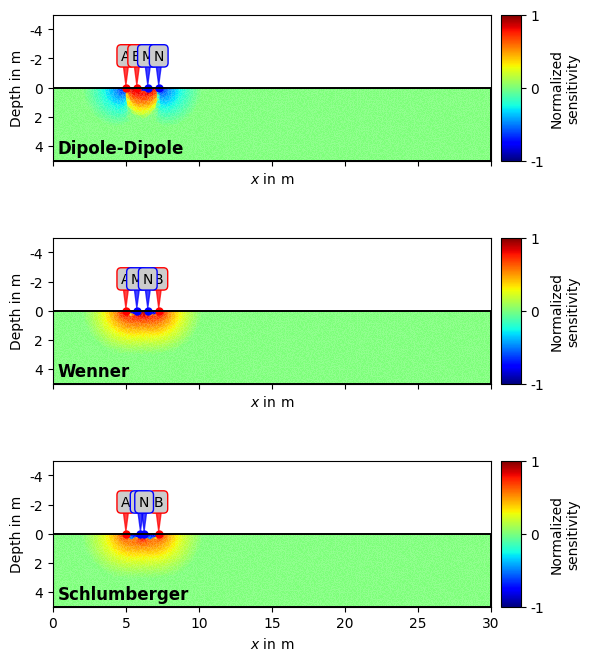

In [31]:
def getABMN(scheme, idx):
    """ Get coordinates of four-point cfg with id `idx` from DataContainerERT
    `scheme`."""
    coords = {}
    for elec in "abmn":
        elec_id = int(scheme(elec)[idx])
        elec_pos = scheme.sensorPosition(elec_id)
        coords[elec] = elec_pos.x(), elec_pos.y()
    return coords


def plotABMN(ax, scheme, idx):
    """ Visualize four-point configuration on given axes. """
    coords = getABMN(scheme, idx)
    for elec in coords:
        x, y = coords[elec]
        if elec in "ab":
            color = "red"
        else:
            color = "blue"
        ax.plot(x, y, marker=".", color=color, ms=10)
        ax.annotate(elec.upper(), xy=(x, y), ha="center", fontsize=10, bbox=dict(
            boxstyle="round", fc=(0.8, 0.8, 0.8), ec=color), xytext=(0, 20),
                    textcoords='offset points', arrowprops=dict(
                        arrowstyle="wedge, tail_width=.5", fc=color, ec=color,
                        patchA=None, alpha=0.75))
        ax.plot(coords["a"][0],)

labels = ["Dipole-Dipole", "Wenner", "Schlumberger"]
fig, ax = plt.subplots(scheme.size(), 1, sharex=True, figsize=(6,8))

for i, sens in enumerate(fop.jacobian()):
    # Label in lower-left corner
    ax[i].text(.01, .15, labels[i], horizontalalignment='left',
               verticalalignment='top', transform=ax[i].transAxes, fontsize=12,
               fontweight="bold")

    # Electrode annotations
    plotABMN(ax[i], scheme, i)

    # Log-scaled and normalized sensitivity
    normsens = pg.utils.logDropTol(sens/mesh.cellSizes(), 8e-4)
    normsens /= np.max(normsens)
    pg.show(mesh, normsens, cMap="jet", ax=ax[i], orientation="vertical",
            label="Normalized\nsensitivity", nLevs=3, cMin=-1, cMax=1)

fig.tight_layout()